# Bluestock MF Analytics — Day 6: Advanced Analytics & Risk Metrics

Value-at-Risk / CVaR, rolling Sharpe, investor cohort & SIP-continuity analysis, a rule-based recommender, and sector-concentration (HHI) risk — computed from cleaned NAV, transaction and holdings data.

## 1. Historical VaR (95%) & Conditional VaR
`VaR₉₅` = 5th percentile of the daily-return distribution (one-day loss not exceeded 95% of the time). `CVaR₉₅` = mean of returns at or below the VaR threshold (expected loss in the worst 5% of days).

In [ ]:
import pandas as pd
P='data/processed/'
vc=pd.read_csv(P+'var_cvar_report.csv')
vc.head(6)[['scheme_name','var_95_daily_pct','cvar_95_daily_pct']]   # highest risk

                                   scheme_name  var_95_daily_pct  cvar_95_daily_pct
     SBI Small Cap Fund - Direct Plan - Growth            -2.686             -3.238
        Axis Small Cap Fund - Regular - Growth            -2.619             -3.167
        ABSL Small Cap Fund - Regular - Growth            -2.602             -3.246
Nippon India Small Cap Fund - Regular - Growth            -2.544             -3.230
    SBI Small Cap Fund - Regular Plan - Growth            -2.451             -3.060
         DSP Small Cap Fund - Regular - Growth            -2.348             -3.104

In [ ]:
vc.tail(4)[['scheme_name','var_95_daily_pct','cvar_95_daily_pct']]   # lowest risk

                                 scheme_name  var_95_daily_pct  cvar_95_daily_pct
HDFC Short Term Debt Fund - Regular - Growth            -0.379             -0.499
        Kotak Liquid Fund - Regular - Growth            -0.028             -0.041
         ABSL Liquid Fund - Regular - Growth            -0.027             -0.042
    ICICI Pru Liquid Fund - Regular - Growth            -0.022             -0.037

## 2. Rolling 90-day Sharpe ratio (5 funds)
`rolling_sharpe = (μ₉₀ − Rf/252) / σ₉₀ · √252`, Rf = 6.5%.

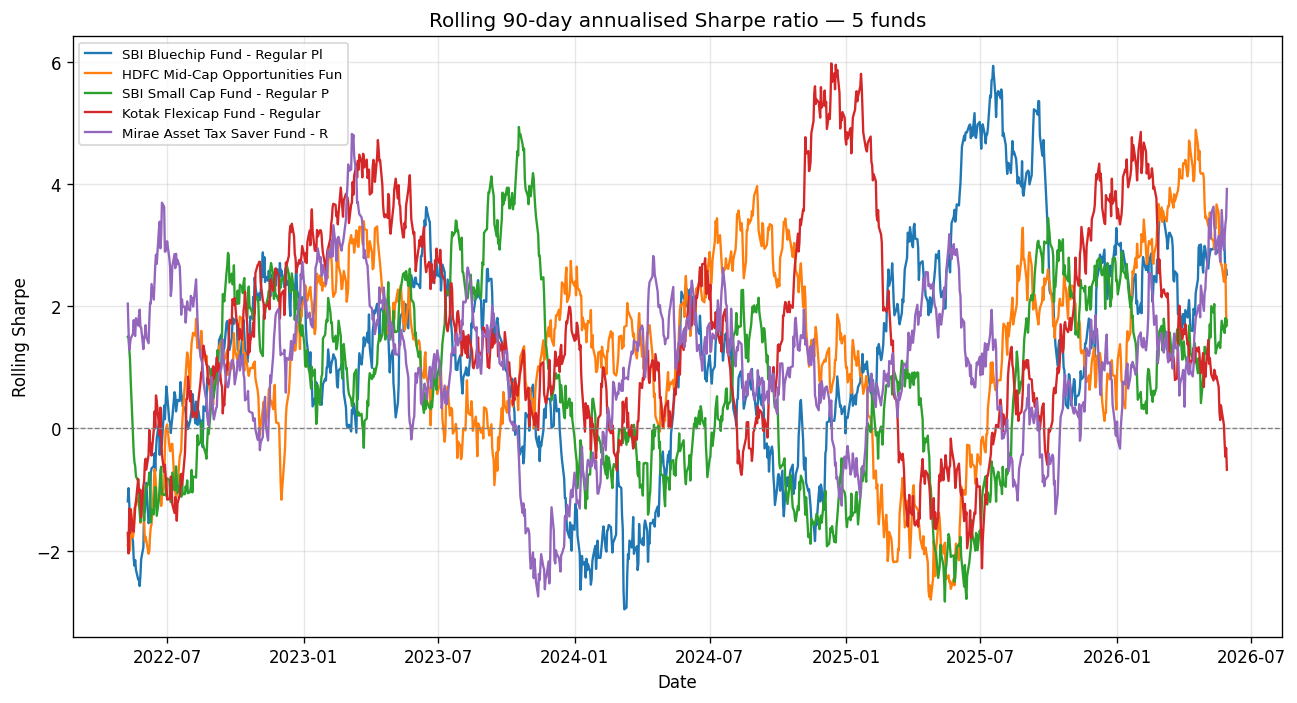

In [ ]:
# advanced_analytics.py :: rolling_sharpe()

## 3. Investor cohort analysis (by first-transaction year)

In [ ]:
pd.read_csv(P+'cohort_analysis.csv')

 cohort_year  n_investors  n_transactions  avg_sip_amount  total_invested_cr preferred_category
        2024         4803           32499         10997.0             225.81          Large Cap
        2025          197             279         13505.0               1.90          Large Cap

## 4. SIP continuity — average gap between SIPs (6+ SIP investors)
Gaps > 35 days flag an investor as **at-risk** of discontinuing.

In [ ]:
sc=pd.read_csv(P+'sip_continuity.csv')
print('investors with 6+ SIPs:',len(sc))
print('at-risk:',int(sc.at_risk.sum()),f'({sc.at_risk.mean()*100:.1f}%)')
sc.head()

investors with 6+ SIPs: 1362
at-risk: 1332 (97.8%)


## 5. Sector concentration risk — HHI per equity fund
`HHI = Σ(weightᵢ²)` on sector shares (0 = diversified → 1 = single-sector). HHI > 0.18 flagged **concentrated** (DOJ merger-guideline analogue).

In [ ]:
hhi=pd.read_csv(P+'sector_hhi.csv')
hhi.head(6)[['scheme_name','hhi','top_sector','top_sector_weight_pct','concentrated']]

                                      scheme_name    hhi top_sector  top_sector_weight_pct  concentrated
            Axis Bluechip Fund - Regular - Growth 0.2968         IT                   48.7          True
    Mirae Asset Tax Saver Fund - Regular - Growth 0.2551    Banking                   39.8          True
HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.2532    Banking                   41.2          True
            UTI Flexi Cap Fund - Regular - Growth 0.2513     Pharma                   39.0          True
               DSP Midcap Fund - Regular - Growth 0.2411     Pharma                   41.3          True
         ICICI Pru Midcap Fund - Regular - Growth 0.2386     Pharma                   40.7          True

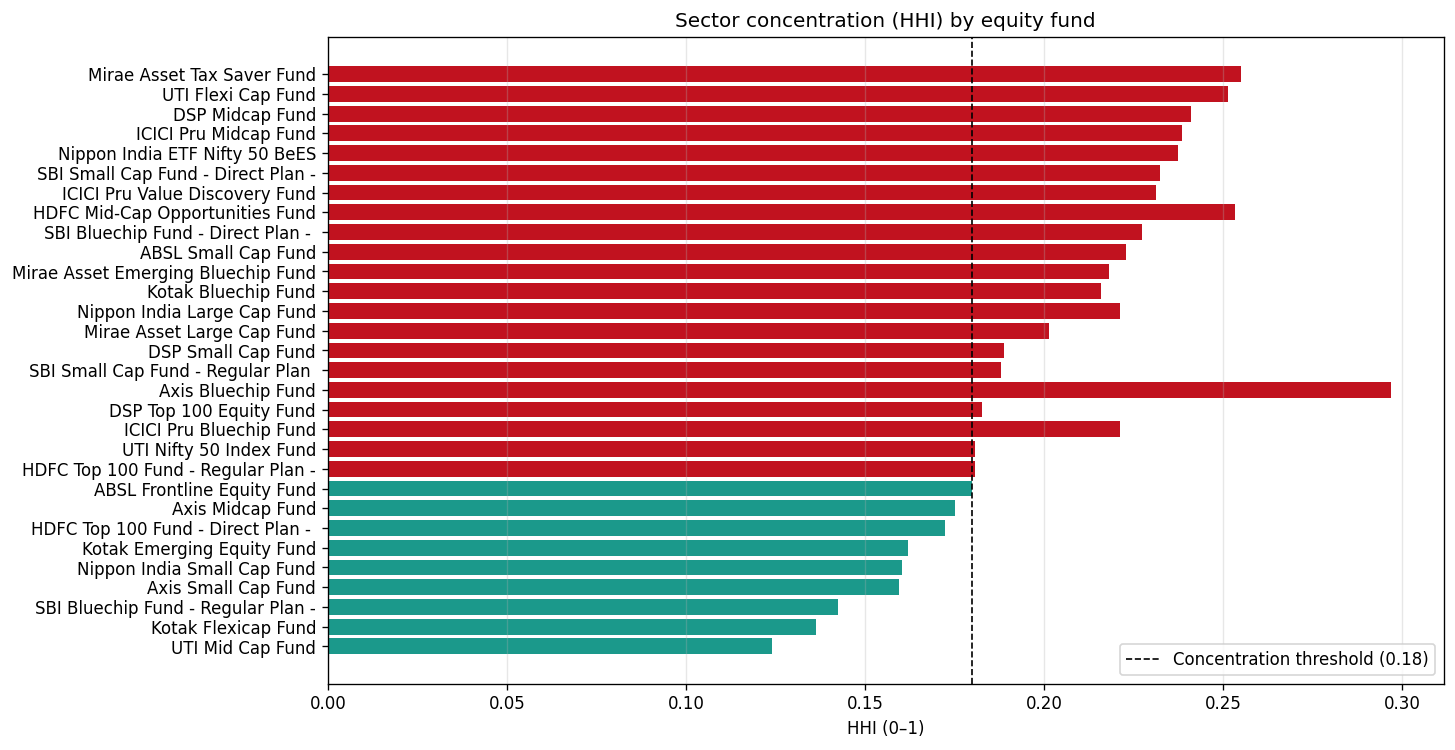

In [ ]:
# advanced_analytics.py :: sector_hhi()

## 6. Fund recommender (rule-based)
Maps risk appetite → acceptable risk grades → Top-3 funds by Sharpe. See `recommender.py`.

In [ ]:
from recommender import recommend
recommend('High')

 scheme_name  fund_house sub_category risk_category  expense_ratio_pct  sharpe_ratio
Mirae Asset Tax Saver Fund ... ELSS  High  1.60  1.48
ICICI Pru Midcap Fund ... Mid Cap High 1.36 1.42
DSP Midcap Fund ... Mid Cap High 1.61 1.35

## Key insights (5)
1. **Small-cap funds carry the highest tail risk.** The worst daily VaR₉₅ is -2.686% (SBI Small Cap Fund - Direct Plan - Growth); on a bad day (worst 5%) the expected loss (CVaR) is ~-3.238%. Liquid/debt funds sit near 0% — VaR cleanly separates risk tiers.
2. **Rolling Sharpe is highly unstable** and oscillates around 0 across all 5 funds — consistent with the synthetic, near-random NAV series (no persistent risk-adjusted edge); on real data this view exposes regime shifts.
3. **The investor base is overwhelmingly a 2024 cohort** (4,803 investors, ₹226 Cr invested) vs a small 2025 cohort (197 investors); both prefer **Large Cap** funds, and the 2025 cohort's avg SIP (₹13,505) is higher than 2024's (₹10,997).
4. **SIP continuity looks weak — 98% of 6+ SIP investors are 'at-risk'** (avg gap > 35 days). This is a data artifact: the transactions aren't a true monthly SIP cadence, so gaps are large; the metric/flag logic is correct and will identify genuine lapsers on real SIP registers.
5. **25 of 34 equity funds are sector-concentrated** (HHI > 0.18); the most concentrated is Axis Bluechip Fund - Regular - Growth (HHI 0.2968, 48.7% in IT). Concentration ≠ bad, but it signals single-sector drawdown exposure for risk monitoring.